In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

In [2]:
MODEL_DIR = Path("D:/storage/models/mask_rcnn_inception_v2_coco_2018_01_28")

with open(MODEL_DIR / "mscoco_labels.names", "r") as f:
    classes = [line.strip() for line in f.readlines()] # if len(class_ := line.strip()) > 0]

with open(MODEL_DIR / "colors.txt", "r") as f:
    colors = [np.array(line.strip().split(" "), dtype=np.float64) for line in f.readlines()]

print(classes)
print(colors)

['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light', 'fire hydrant', '', 'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', '', 'backpack', 'umbrella', '', '', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket', 'bottle', '', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', '', 'dining table', '', '', 'toilet', '', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', '', 'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush']
[array([  0., 255.,   0.]), array([  0.,   0., 255.]), array([255.,   0.,   0.]), array([  0., 255

In [3]:
import cv2 as cv
import numpy as np
import random

class BboxData:
    def __init__(self, box, img_w, img_h):
        self.score = float(box[2])
        self.class_id = int(box[1])

        # Helper to scale and clamp coordinates in one pass
        def scale_clip(val, limit):
            return max(0, min(int(val * limit), limit - 1))

        self.left = scale_clip(box[3], img_w)
        self.top = scale_clip(box[4], img_h)
        self.right = scale_clip(box[5], img_w)
        self.bottom = scale_clip(box[6], img_h)

    @property
    def size(self):
        return (self.right - self.left + 1, self.bottom - self.top + 1)

def draw_box(frame, box, class_mask, classes, colors, mask_threshold=0.3):
    cv.rectangle(frame, (box.left, box.top), (box.right, box.bottom), (255, 178, 50), 3)

    label = f"{classes[box.class_id] if classes else ''}:{box.score:.2f}"
    (label_w, label_h), baseline = cv.getTextSize(label, cv.FONT_HERSHEY_SIMPLEX, 0.5, 1)

    label_top = max(box.top, label_h)
    cv.rectangle(frame, (box.left, label_top - label_h - baseline),
                 (box.left + label_w, label_top), (255, 255, 255), cv.FILLED)
    cv.putText(frame, label, (box.left, label_top - baseline),
               cv.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1)

    # Process Mask
    res_mask = cv.resize(class_mask, box.size)
    mask_bool = res_mask > mask_threshold
    roi = frame[box.top : box.bottom + 1, box.left : box.right + 1]

    color = random.choice(colors)

    # Blending the color into the ROI
    roi[mask_bool] = (0.3 * np.array(color) + 0.7 * roi[mask_bool]).astype(np.uint8)

    # Contours
    contours, _ = cv.findContours(mask_bool.astype(np.uint8), cv.RETR_TREE, cv.CHAIN_APPROX_SIMPLE)
    cv.drawContours(roi, contours, -1, color, 3)

def postprocess(img, boxes, masks, classes, colors, conf_threshold=0.3):
    h, w = img.shape[:2]

    for i in range(boxes.shape[2]):
        box = BboxData(boxes[0, 0, i], w, h)

        if box.score > conf_threshold:
            draw_box(img, box, masks[i, box.class_id], classes, colors)

In [4]:
net = cv.dnn.readNetFromTensorflow(
    MODEL_DIR / "frozen_inference_graph.pb",
    MODEL_DIR / "mask_rcnn_inception_v2_coco_2018_01_28.pbtxt"
)

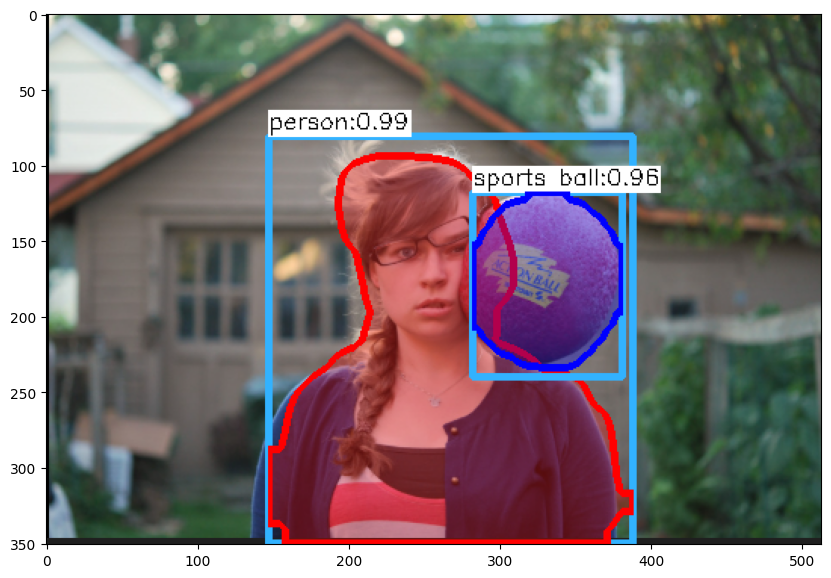

In [5]:
img = cv.imread("../../images/girl_with_ball.png")

blob = cv.dnn.blobFromImage(img, swapRB=True, crop=False)

net.setInput(blob)

bboxes, masks = net.forward(['detection_out_final', 'detection_masks'])

postprocess(img, bboxes, masks, classes, colors)

plt.figure(figsize=[10,10])
plt.imshow(img[...,::-1])